
# Tracing the OVRO&#8211;LWA type II burst with B&#233;zier curves &#8212; 18 January 2026

Trace the band-split type II radio burst in the **OVRO&#8211;LWA** dynamic spectrum with
**B&#233;zier curves** (start, end and one/two anchor points, placed interactively), then
report the shock diagnostics through a grid of **electron-density models &#215; fold numbers**
with Monte-Carlo error bars.

**Chain.** Interactive B&#233;zier placement in the dynamic-spectrum index space
&#8594; frequency lanes $f(t)$ for the fundamental (F) and harmonic (H) bands, each split into a
**lower** and **upper** branch &#8594; density models $n_e(r)$ &#8594; height $r(t)$, drift rate,
band-split density jump $X=(f_U/f_L)^2$, Alfv&#233;n Mach number $M_A$, shock speed/acceleration,
exciter electron energy, Alfv&#233;n speed and coronal magnetic field $B$.

**What carries the uncertainty.** Each committed B&#233;zier curve is re-sampled as a *jittered
ensemble* (Gaussian perturbation of the control points), and every lane polynomial is resampled
from its covariance in a Monte-Carlo loop. The two together give the statistical error bars.
The dominant *systematic* is the density model itself, shown explicitly as the spread across the
model &#215; fold grid.

**Density models (each at folds 1&#8211;4):** Newkirk (1961), Saito (1970), Leblanc, Dulk & Bougeret
(1998), Baumbach&#8211;Allen (Allen 1947), Mann, Warmuth, Vocks & Rouillard (2023, *A&amp;A* 679, A64).
**Field comparison:** Dulk & McLean (1978), Gopalswamy & Yashiro (2011), Mann et al. (2023).

> Set `DEMO_MODE = True` in the config to run the whole notebook end-to-end on a **synthetic**
> band-split type II (no widget needed) &#8212; useful for a first pass or a headless check. Set it to
> `False` to trace the real OVRO&#8211;LWA spectrum interactively.

## 0&#160;&#183;&#160;Imports, constants and configuration

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors

from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

from astropy.io import fits
from astropy.time import Time
from astropy.constants import R_sun, m_e, m_p, e, eps0, mu0, c

warnings.filterwarnings('ignore', category=RuntimeWarning)

# --- physical constants pulled from astropy (no hardcoding of the physics) ---
R_SUN_M    = R_sun.to('m').value
C_MS       = c.to('m/s').value
E_CHARGE_J = e.si.value
M_E        = m_e.value
M_P        = m_p.value
EPS0       = eps0.value
MU0        = mu0.value

# electron plasma frequency: f_p[Hz] = PLASMA_CONST * sqrt(Ne[cm^-3])  (~8.98e3)
PLASMA_CONST = (1 / (2 * np.pi)) * np.sqrt(1e6 * E_CHARGE_J ** 2 / (EPS0 * M_E))
print(f'PLASMA_CONST = {PLASMA_CONST:.4g}  (f_pe[Hz] = PLASMA_CONST * sqrt(Ne[cm^-3]))')

PLASMA_CONST = 8979  (f_pe[Hz] = PLASMA_CONST * sqrt(Ne[cm^-3]))


In [11]:
# =========================== CONFIGURATION ===========================
DEMO_MODE = False                 # True -> synthetic self-test (no widget); False -> trace the real spectrum

# --- event / data ---
EVENT_DATE = '2026-01-18'
DATA_ROOT  = '/home/mnedal/data/'                                        # set to '/home/mnedal/data' on the DIAS server
LWA_FITS   = f'{DATA_ROOT}/{EVENT_DATE}/LWA/20260118.fits'
OUTDIR     = './type2_lwa_bezier_outputs'
os.makedirs(OUTDIR, exist_ok=True)

# --- tracing window on the dynamic spectrum ---
TYPEII_WINDOW = (pd.Timestamp(f'{EVENT_DATE}T17:55:00'), pd.Timestamp(f'{EVENT_DATE}T18:14:00'))
TYPEII_FLIM   = [16, 80]                                 # MHz, tracing band
RADIO_BKG_WINDOW = (pd.Timestamp(f'{EVENT_DATE}T16:30:00'), pd.Timestamp(f'{EVENT_DATE}T17:00:00'))
LWA_POL_PLANE = 0                                        # 0 = Stokes I (confirm plane order with the data provider)

# --- emission physics ---
HARM = {'F': 1, 'H': 2}          # harmonic number per band (F = fundamental, H = harmonic)
MU   = 1.27                      # mean molecular weight per electron (10% He corona)

# --- density-model grid ---
FOLDS = [1, 2, 3, 4]             # fold numbers applied to every model
REF_MODEL_NAME = 'Newkirk x2'    # model x fold used for the reference per-lane figure

# --- Bezier tracing (interactive placement, jittered-ensemble error) ---
BEZIER_ANCHORS   = {('F', 'lower'): 1, ('F', 'upper'): 1,   # 1 -> quadratic, 2 -> cubic (per lane)
                    ('H', 'lower'): 1, ('H', 'upper'): 1}
BEZIER_NUM_POINTS = 80           # samples along each Bezier curve
BEZIER_N_REPEATS  = 5            # jittered repeats per lane (repeat 0 is unperturbed)
BEZIER_JITTER     = 1.5          # control-point jitter sigma, in dynamic-spectrum index pixels
BEZIER_SEED       = 0

# --- Monte-Carlo ---
N_MC = 100                       # MC draws per pass for the fit error

def save_fig(fig, name, dpi=300):
    path = os.path.join(OUTDIR, f'{name}.png')
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print('saved', path)

print(f'DEMO_MODE = {DEMO_MODE}')
print(f'type II window {TYPEII_WINDOW[0].time()}-{TYPEII_WINDOW[1].time()} UT, {TYPEII_FLIM} MHz')

DEMO_MODE = False
type II window 17:55:00-18:14:00 UT, [16, 80] MHz



## 1&#160;&#183;&#160;Load the OVRO&#8211;LWA dynamic spectrum

Reads the beam dynamic-spectrum FITS (`npol, 1, nfreq, ntime`; `SFREQ` in GHz, `UT` = integer MJD
+ ms-of-day), slices the type II window and band, and builds the **background-ratioed** tracing
layer (each channel divided by its quiet pre-flare median). Under `DEMO_MODE` a synthetic
band-split type II is fabricated instead, so the notebook runs without the file or a widget.

In [12]:
def load_lwa_dyspec(path, pol_plane=0):
    """OVRO-LWA dynamic-spectrum FITS. Returns (DatetimeIndex, freq[MHz], spec[nfreq, ntime])."""
    with fits.open(path) as hdul:
        cube = hdul[0].data[:, 0, :, :]                     # (npol, nfreq, ntime)
        fmhz = hdul['SFREQ'].data['SFREQ'] * 1e3            # GHz -> MHz
        ut = hdul['UT'].data
        time_mjd = ut['mjd'] + ut['time'] / 86400000
    t_index = pd.DatetimeIndex(Time(time_mjd, format='mjd').to_datetime())
    return t_index, np.asarray(fmhz), np.asarray(cube[pol_plane])


def make_typeii_layer(t_index, freqs, spec, window, flim, bkg_window):
    """Background-ratioed spectrogram slice (spec / per-channel pre-flare median) over the
    tracing window and band. Returns (t[window], f[band], layer[nf, nt])."""
    sel_t = (t_index >= window[0]) & (t_index <= window[1])
    sel_f = (freqs >= flim[0]) & (freqs <= flim[1])
    bsel  = (t_index >= bkg_window[0]) & (t_index <= bkg_window[1])
    bkg = np.nanmedian(spec[np.ix_(sel_f, bsel)].astype(float), axis=1)[:, None]
    with np.errstate(all='ignore'):
        layer = spec[np.ix_(sel_f, sel_t)].astype(float) / bkg
    return t_index[sel_t], freqs[sel_f], layer


def synth_typeii_layer(window, flim, cadence_s=0.514):
    """Fabricate a band-split type II for DEMO_MODE: two drifting F branches (lower/upper) plus
    their harmonic (x2 in frequency). Known drift and density jump so the chain can be checked."""
    t = pd.date_range(window[0], window[1], freq=f'{cadence_s}s')
    f = np.arange(flim[0], flim[1] + 0.25, 0.25)                       # MHz axis (ascending)
    ts = (t - t[0]).total_seconds().to_numpy()
    dur = ts[-1]
    # fundamental lower branch: 28 -> 18 MHz (F band); harmonic (x2) 56 -> 36 MHz stays in-band
    fL = 28 - 8 * (ts / dur) - 2.0 * (ts / dur) ** 2
    fU = fL * 1.09                                                     # 9% band split -> X = 1.19
    layer = np.full((f.size, t.size), 0.15)
    def paint(track, s):                                              # s = harmonic (1 F, 2 H)
        for j, tv in enumerate(track * s):
            k = np.argmin(np.abs(f - tv))
            lo, hi = max(0, k - 3), min(f.size, k + 4)
            layer[lo:hi, j] += np.exp(-0.5 * ((f[lo:hi] - tv) / 0.6) ** 2)
    for tr in (fL, fU):
        paint(tr, 1)                                                  # F band
        paint(tr, 2)                                                  # H band (2x frequency)
    layer += np.random.default_rng(1).normal(0, 0.03, layer.shape)
    return t, f, np.clip(layer, 1e-3, None), dict(fL=fL, fU=fU, ts=ts)


if DEMO_MODE:
    t2_t, t2_f, t2_layer, _synth = synth_typeii_layer(TYPEII_WINDOW, TYPEII_FLIM)
    print(f'DEMO synthetic layer: {t2_layer.shape[0]} channels x {t2_layer.shape[1]} times, '
          f'{t2_f[0]:.1f}-{t2_f[-1]:.1f} MHz')
else:
    lwa_t, lwa_f, lwa_s = load_lwa_dyspec(LWA_FITS, LWA_POL_PLANE)
    print(f'{len(lwa_f)} channels, {len(lwa_t)} times, {lwa_f[0]:.1f}-{lwa_f[-1]:.1f} MHz')
    t2_t, t2_f, t2_layer = make_typeii_layer(lwa_t, lwa_f, lwa_s,
                                             TYPEII_WINDOW, TYPEII_FLIM, RADIO_BKG_WINDOW)
    _synth = None

NT, NF = t2_layer.shape[1], t2_layer.shape[0]
print(f'tracing array (freq, time) = {t2_layer.shape}')

731 channels, 53385 times, 15.0-84.9 MHz
tracing array (freq, time) = (668, 2103)


saved ./type2_lwa_bezier_outputs/lwa_typeii_window.png


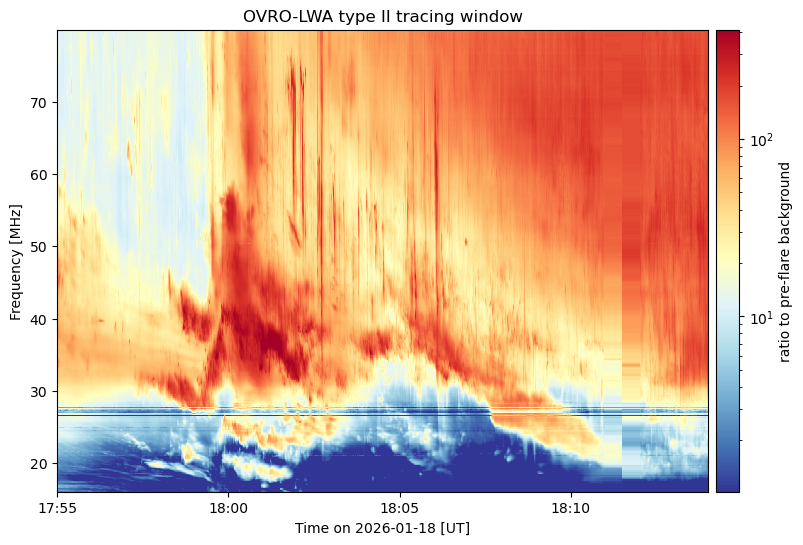

In [13]:
# quicklook of the tracing layer (this is the canvas the Bezier curves are drawn on)
fig, ax = plt.subplots(figsize=[10,6])
pm = ax.pcolormesh(t2_t, t2_f, t2_layer,
                   norm=colors.LogNorm(vmin=np.nanpercentile(t2_layer, 5),
                                       vmax=np.nanpercentile(t2_layer, 99.9)),
                   cmap='RdYlBu_r', rasterized=True)
fig.colorbar(pm, ax=ax, pad=0.01, label='ratio to pre-flare background')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel(f'Time on {EVENT_DATE} [UT]')
ax.set_ylabel('Frequency [MHz]')
ax.set_title('OVRO-LWA type II tracing window' + ('  (synthetic)' if DEMO_MODE else ''))
save_fig(fig, 'lwa_typeii_window')
plt.show()


## 2&#160;&#183;&#160;Electron-density models &#215; fold numbers

Each model returns $n_e(r)$ in cm$^{-3}$ for heliocentric distance $r$ in solar radii, and is
scaled by a **fold** factor (density enhancement over the quiet Sun). The observed frequency maps
to a local density $n_e=(f/(s\,f_1))^2$ with $s=1$ (F) or $2$ (H), which each model inverts to a
source height. Density jump $X=(f_U/f_L)^2$ and $M_A$ are **model-independent**; height, speed,
$v_A$ and $B$ are not &#8212; that spread is the systematic explored later.

In [14]:
def newkirk(r, fold=1):
    """Newkirk (1961), exponential quiet-corona model."""
    r = np.asarray(r, float)
    return fold * 4.2e4 * 10.0 ** (4.32 / r)

def saito(r, fold=1):
    """Saito (1970), equatorial two-term fit."""
    r = np.asarray(r, float)
    return fold * (1.36e6 * r ** -2.14 + 1.68e8 * r ** -6.13)

def leblanc(r, fold=1):
    """Leblanc, Dulk & Bougeret (1998), low corona to 1 AU."""
    r = np.asarray(r, float)
    return fold * (3.3e5 * r ** -2 + 4.1e6 * r ** -4 + 8.0e7 * r ** -6)

def baumbach_allen(r, fold=1):
    """Baumbach (1937) eclipse fit with Allen (1947) dust correction, three-term."""
    r = np.asarray(r, float)
    return fold * 1e8 * (0.036 * r ** -1.5 + 1.55 * r ** -6 + 2.99 * r ** -16)

def mann2023(r, fold=1):
    """Mann, Warmuth, Vocks & Rouillard (2023), A&A 679, A64, Eq. 18 (barometric, PSP-calibrated;
    valid r <~ 3 Rsun). n_e = 7.17e8 * exp(11.14 * (1/r - 1)). The constant 11.14 (their text)
    reproduces the paper's quoted n_e(3 Rsun) = 4.267e5 cm^-3; the printed Eq. 18 shows 11.35."""
    r = np.asarray(r, float)
    return fold * 7.17e8 * np.exp(11.14 * (1.0 / r - 1.0))

BASE_MODELS = {'Newkirk': newkirk, 'Saito': saito, 'Leblanc': leblanc,
               'Baumbach-Allen': baumbach_allen, 'Mann 2023': mann2023}

# every model x fold, bound as a single-argument callable model(r)
MODEL_GRID = {f'{name} x{fold}': (lambda r, _f=fun, _k=fold: _f(r, fold=_k))
              for name, fun in BASE_MODELS.items() for fold in FOLDS}
print(f'{len(BASE_MODELS)} models x {len(FOLDS)} folds = {len(MODEL_GRID)} combinations')


def freq_to_density(f_hz, harmonic=1):
    """Plasma-frequency -> local electron density [cm^-3] for emission at the given harmonic."""
    return (np.asarray(f_hz, float) / harmonic / PLASMA_CONST) ** 2

def freq_to_radius(f_hz, model, harmonic=1, r_bounds=(1.0, 5.0), nres=6000):
    """Invert a monotonically decreasing n_e(r) for the source height (vectorised);
    out-of-range densities -> NaN."""
    rr = np.linspace(r_bounds[0], r_bounds[1], nres)
    ne = model(rr)
    ne_t = freq_to_density(np.atleast_1d(f_hz), harmonic=harmonic)
    r = np.interp(ne_t, ne[::-1], rr[::-1])
    r[(ne_t > np.nanmax(ne)) | (ne_t < np.nanmin(ne))] = np.nan
    return r if r.size > 1 else float(r[0])

def alfven_mach_from_X(X, gamma=5/3):
    """Perpendicular-shock M_A from the density jump X (Rankine-Hugoniot); valid 1 <= X < 4."""
    X = np.asarray(X, float)
    out = np.full(X.shape, np.nan)
    ok = (X >= 1) & (X < 4)
    out[ok] = np.sqrt(X[ok] * (X[ok] + 5) / (2 * (4 - X[ok])))
    return out

5 models x 4 folds = 20 combinations


saved ./type2_lwa_bezier_outputs/density_models_grid.png


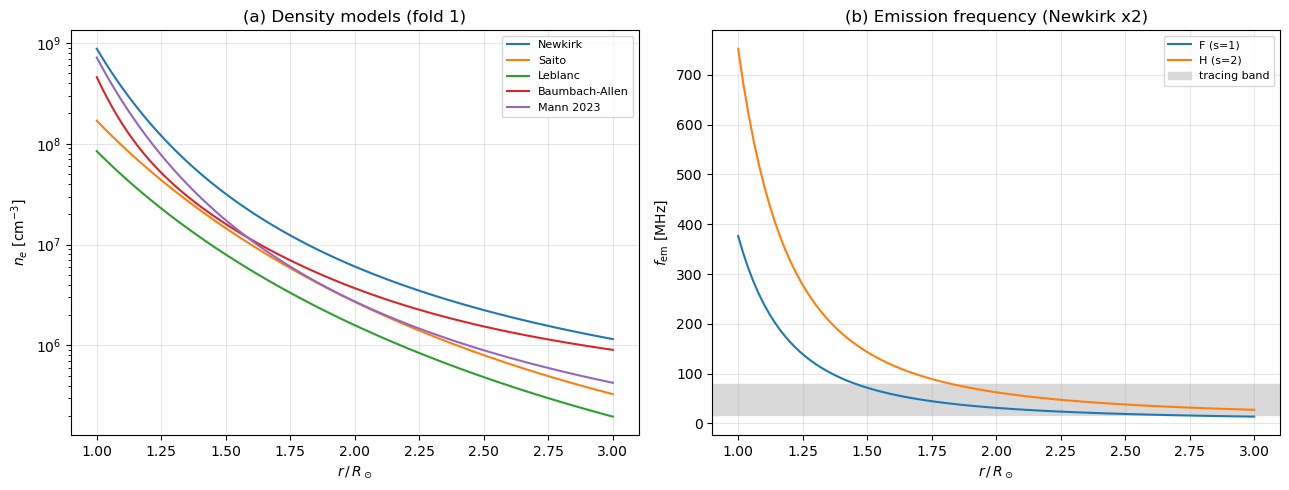

In [15]:
# n_e(r) grid and the frequency-height mapping the tracing relies on
rr = np.linspace(1, 3, 100)
fig, (axn, axf) = plt.subplots(1, 2, figsize=[13,5])
for name, fun in BASE_MODELS.items():
    axn.plot(rr, fun(rr, fold=1), label=name)
axn.set_yscale('log')
axn.set_xlabel(r'$r\,/\,R_\odot$')
axn.set_ylabel(r'$n_e$ [cm$^{-3}$]')
axn.set_title('(a) Density models (fold 1)')
axn.legend(fontsize=8)
axn.grid(alpha=0.3)

# emission frequency f_em(r) = s * f_pe for the reference model, F and H
ref = MODEL_GRID[REF_MODEL_NAME]
for s, lab in [(1, 'F (s=1)'), (2, 'H (s=2)')]:
    axf.plot(rr, s * PLASMA_CONST * np.sqrt(ref(rr)) / 1e6, label=lab)
axf.axhspan(TYPEII_FLIM[0], TYPEII_FLIM[1], color='0.85', label='tracing band')
axf.set_xlabel(r'$r\,/\,R_\odot$'); axf.set_ylabel(r'$f_{\rm em}$ [MHz]')
axf.set_title(f'(b) Emission frequency ({REF_MODEL_NAME})')
axf.legend(fontsize=8, loc='upper right'); axf.grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, 'density_models_grid')
plt.show()


## 3&#160;&#183;&#160;B&#233;zier-curve tracing of the band-split lanes

The type II is traced with **B&#233;zier curves** placed on the dynamic spectrum in *index space*
(x = time frame, y = frequency channel). A quadratic curve has one anchor, a cubic has two
(`BEZIER_ANCHORS` sets this per lane). Four lanes are traced: the fundamental (F) and harmonic (H)
bands, each split into a **lower** and **upper** branch.

Each committed curve is expanded into a **jittered ensemble**: the start, end and anchors are
perturbed by Gaussian noise of width `BEZIER_JITTER` pixels `BEZIER_N_REPEATS` times (the first
repeat is unperturbed). Those repeats become the tracing "passes", so the spread reflects how
sensitive the diagnostics are to where the curve was placed.

In [16]:
def draw_bezier(x1=0, y1=0, x2=0, y2=0, controls=[[0, 0]], n=2, num_points=30):
    """Bezier curve of degree n from (x1,y1) to (x2,y2) with n-1 control points.
    n=1 linear, n=2 quadratic (1 anchor), n=3 cubic (2 anchors). Returns (num_points, 2)."""
    P0 = np.array([x1, y1], dtype=float)
    P3 = np.array([x2, y2], dtype=float)
    t = np.linspace(0, 1, num_points)
    if n == 1:
        curve = (1 - t)[:, None] * P0 + t[:, None] * P3
    elif n == 2:
        P1 = np.array(controls[0], dtype=float)
        curve = ((1 - t)[:, None] ** 2 * P0
                 + 2 * (1 - t)[:, None] * t[:, None] * P1
                 + t[:, None] ** 2 * P3)
    elif n == 3:
        P1 = np.array(controls[0], dtype=float)
        P2 = np.array(controls[1], dtype=float)
        curve = ((1 - t)[:, None] ** 3 * P0
                 + 3 * (1 - t)[:, None] ** 2 * t[:, None] * P1
                 + 3 * (1 - t)[:, None] * t[:, None] ** 2 * P2
                 + t[:, None] ** 3 * P3)
    else:
        raise ValueError('n must be 1 (linear), 2 (quadratic) or 3 (cubic).')
    return curve


def extract_bezier_values(array, x1, y1, x2, y2, controls, n, num_points):
    """Sample `array` (indexed [y, x]) along the Bezier curve; returns (values, x_idx, y_idx)
    as integer pixel indices clipped to the array bounds."""
    curve = draw_bezier(x1, y1, x2, y2, controls, n, num_points)
    x_coords = np.clip(np.round(curve[:, 0]).astype(int), 0, array.shape[1] - 1)
    y_coords = np.clip(np.round(curve[:, 1]).astype(int), 0, array.shape[0] - 1)
    values = array[y_coords, x_coords]
    return values, x_coords, y_coords


def bezier_freq_lane(times, freqs, x_idx, y_idx):
    """Map integer (time-idx, freq-idx) curve samples to a {'t':[...], 'f':[...]} lane
    (frequencies in MHz), sorted in time, duplicates in time collapsed."""
    t_sel = pd.to_datetime([times[i] for i in x_idx])
    f_val = np.asarray(freqs, float)[y_idx]
    x_num = mdates.date2num(t_sel)
    order = np.argsort(x_num)
    t_sorted = np.asarray(t_sel)[order]
    f_sorted = f_val[order]
    xn = x_num[order]
    _, uniq = np.unique(xn, return_index=True)          # strictly increasing time for the fits
    return {'t': list(t_sorted[uniq]), 'f': list(f_sorted[uniq])}


def make_bezier_passes(specs, times, freqs, array, n_repeats=BEZIER_N_REPEATS,
                       jitter=BEZIER_JITTER, num_points=BEZIER_NUM_POINTS, seed=BEZIER_SEED):
    """Build the `passes` list (pas[band][branch] = {'t','f'}) from per-lane Bezier specs.
    specs[(band,branch)] = dict(p_start=(x,y), p_end=(x,y), anchors=[(x,y), ...]) in index space.
    The k-th jittered curve of every lane forms pass k, so lanes stay coherent within a pass."""
    rng = np.random.default_rng(seed)
    lanes = [('F', 'lower'), ('F', 'upper'), ('H', 'lower'), ('H', 'upper')]
    per_lane = {}
    for ln in lanes:
        sp = specs.get(ln)
        if sp is None:
            per_lane[ln] = None
            continue
        base = np.array([sp['p_start'], sp['p_end'], *sp['anchors']], float)
        n = len(sp['anchors']) + 1
        reps = []
        for r in range(n_repeats):
            pert = base if (r == 0 or jitter <= 0) else base + rng.normal(0, jitter, base.shape)
            (sx, sy), (ex, ey) = pert[0], pert[1]
            ctrl = [list(p) for p in pert[2:]]
            _, xi, yi = extract_bezier_values(array, sx, sy, ex, ey, ctrl, n, num_points)
            reps.append(bezier_freq_lane(times, freqs, xi, yi))
        per_lane[ln] = reps
    passes = []
    for k in range(n_repeats):
        pas = {b: {p: {'t': [], 'f': []} for p in ('lower', 'upper')} for b in ('F', 'H')}
        for ln in lanes:
            if per_lane[ln] is not None:
                pas[ln[0]][ln[1]] = per_lane[ln][k]
        passes.append(pas)
    n_traced = sum(v is not None for v in per_lane.values())
    print(f'built {len(passes)} passes from {n_traced} traced lane(s)')
    return passes

In [17]:
# ---- interactive placement: run one cell per lane, adjust the sliders, then commit ----
# (index-space sliders; the live green curve is what will be stored. Skipped under DEMO_MODE.)
_LIVE = {}                       # (band, branch) -> dict(p_start, p_end, anchors)  [latest slider state]
bezier_specs = {}                # committed curves used to build the passes

def trace_lane(band, branch):
    """Show index-space sliders + a live Bezier preview for one lane; store the latest state."""
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, fixed
    
    n_anchors = BEZIER_ANCHORS[(band, branch)]
    Nf, Nt = t2_layer.shape
    ext = [0, Nt, 0, Nf]
    base_y = 0.62 if branch == 'lower' else 0.74           # upper branch sits a little higher
    if band == 'H':
        base_y = min(0.95, base_y + 0.15)
    d = dict(xs=int(0.10 * Nt), xe=int(0.90 * Nt),
             ys=int(base_y * Nf), ye=int((base_y - 0.30) * Nf),
             a1x=int(0.50 * Nt), a1y=int((base_y - 0.10) * Nf),
             a2x=int(0.70 * Nt), a2y=int((base_y - 0.22) * Nf))
    vmin, vmax = np.nanpercentile(t2_layer, 5), np.nanpercentile(t2_layer, 99.9)

    def _upd(x_start, y_start, x_end, y_end, cx1, cy1, cx2, cy2):
        anchors = [(cx1, cy1)] if n_anchors == 1 else [(cx1, cy1), (cx2, cy2)]
        curve = draw_bezier(x_start, y_start, x_end, y_end, anchors, n_anchors + 1, BEZIER_NUM_POINTS)
        _LIVE[(band, branch)] = dict(p_start=(x_start, y_start), p_end=(x_end, y_end), anchors=anchors)
        
        fig, ax = plt.subplots(figsize=[10,6])
        ax.imshow(t2_layer, origin='lower', aspect='auto', extent=ext,
                  norm=colors.LogNorm(vmin=vmin, vmax=vmax), cmap='RdYlBu_r')
        ax.plot(curve[:, 0], curve[:, 1], '-', color='lime', lw=2.2)
        ax.plot([x_start, x_end], [y_start, y_end], 'wo', ms=6)
        for (axx, ayy) in anchors:
            ax.plot(axx, ayy, 'w^', ms=9)
        xt = np.linspace(0, Nt - 1, 5).astype(int)
        ax.set_xticks(xt)
        ax.set_xticklabels([pd.Timestamp(t2_t[i]).strftime('%H:%M:%S') for i in xt], rotation=20, fontsize=8)
        yt = np.linspace(0, Nf - 1, 6).astype(int)
        ax.set_yticks(yt)
        ax.set_yticklabels([f'{t2_f[i]:.0f}' for i in yt])
        ax.set_xlabel('Time [UT]')
        ax.set_ylabel('Frequency [MHz]')
        kind = 'quadratic (1 anchor)' if n_anchors == 1 else 'cubic (2 anchors)'
        ax.set_title(f'Place  {band}-{branch}   [{kind}]  -  adjust sliders, then run the commit cell')
        plt.show()

    interact(_upd,
             x_start=IntSlider(d['xs'], 0, Nt - 1, 1), y_start=IntSlider(d['ys'], 0, Nf - 1, 1),
             x_end=IntSlider(d['xe'], 0, Nt - 1, 1),   y_end=IntSlider(d['ye'], 0, Nf - 1, 1),
             cx1=IntSlider(d['a1x'], 0, Nt - 1, 1),    cy1=IntSlider(d['a1y'], 0, Nf - 1, 1),
             cx2=(IntSlider(d['a2x'], 0, Nt - 1, 1) if n_anchors == 2 else fixed(0)),
             cy2=(IntSlider(d['a2y'], 0, Nf - 1, 1) if n_anchors == 2 else fixed(0)))

def commit_lanes():
    """Copy the latest slider state of every placed lane into bezier_specs."""
    for k, v in _LIVE.items():
        bezier_specs[k] = dict(p_start=tuple(v['p_start']), p_end=tuple(v['p_end']),
                               anchors=[tuple(a) for a in v['anchors']])
    print('committed lanes:', ', '.join(sorted(f'{b}-{p}' for (b, p) in bezier_specs)) or '(none)')

print('Interactive tracer ready. Run the four trace_lane cells below (or use DEMO_MODE).')

Interactive tracer ready. Run the four trace_lane cells below (or use DEMO_MODE).


**Trace each lane** (`%matplotlib widget` must be active for live sliders). Adjust the
start/end (white circles) and anchor(s) (white triangles) so the green curve follows the lane, then
move on. When all four are placed, run the **commit** cell.

In [19]:
%matplotlib widget
if not DEMO_MODE:
    trace_lane('F', 'lower')
else:
    print('DEMO_MODE: skipping widget; synthetic curves are set in the commit cell.')

interactive(children=(IntSlider(value=210, description='x_start', max=2102), IntSlider(value=414, description=…

In [21]:
# if not DEMO_MODE:
#     trace_lane('F', 'upper')

In [22]:
if not DEMO_MODE:
    trace_lane('H', 'lower')

interactive(children=(IntSlider(value=210, description='x_start', max=2102), IntSlider(value=514, description=…

In [23]:
# if not DEMO_MODE:
#     trace_lane('H', 'upper')

In [24]:
# ---- commit the traced lanes (or fabricate them under DEMO_MODE) and build the passes ----
def _demo_specs():
    """Index-space Bezier specs straight from the synthetic tracks (bypasses the widget)."""
    ts, fL, fU = _synth['ts'], _synth['fL'], _synth['fU']
    def idx(track_mhz):
        xs = np.linspace(0, NT - 1, 5).astype(int)                 # 5 control points along time
        pts = []
        for x in xs:
            j = int(round(x / (NT - 1) * (len(ts) - 1)))
            pts.append((int(x), int(np.argmin(np.abs(t2_f - track_mhz[j])))))
        return pts
    specs = {}
    for (band, branch), track in [(('F', 'lower'), fL), (('F', 'upper'), fU),
                                  (('H', 'lower'), 2 * fL), (('H', 'upper'), 2 * fU)]:
        pts = idx(track)
        na = BEZIER_ANCHORS[(band, branch)]
        anchors = [pts[2]] if na == 1 else [pts[1], pts[3]]
        specs[(band, branch)] = dict(p_start=pts[0], p_end=pts[-1], anchors=anchors)
    return specs

if DEMO_MODE:
    bezier_specs = _demo_specs()
    print('DEMO_MODE synthetic specs for:', ', '.join(f'{b}-{p}' for (b, p) in bezier_specs))
else:
    commit_lanes()

passes = make_bezier_passes(bezier_specs, t2_t, t2_f, t2_layer)

committed lanes: F-lower, F-upper, H-lower
built 5 passes from 3 traced lane(s)


In [ ]:
# preview: committed mean curves + jittered ensemble on the dynamic spectrum
fig, ax = plt.subplots(figsize=[12, 6])
pm = ax.pcolormesh(t2_t, t2_f, t2_layer,
                   norm=colors.LogNorm(vmin=np.nanpercentile(t2_layer, 35),
                                       vmax=np.nanpercentile(t2_layer, 99)),
                   cmap='RdYlBu_r', rasterized=True)
fig.colorbar(pm, ax=ax, pad=0.01, label='ratio to pre-flare background')
LANE_COLOR = {('F', 'lower'): 'navy', ('F', 'upper'): 'lime',
              ('H', 'lower'): 'cyan', ('H', 'upper'): 'magenta'}
for (band, branch) in bezier_specs:
    for k, pas in enumerate(passes):
        L = pas[band][branch]
        if L['f']:
            ax.plot(pd.to_datetime(L['t']), L['f'], color=LANE_COLOR[(band, branch)],
                    lw=(2.0 if k == 0 else 0.6), alpha=(1.0 if k == 0 else 0.35),
                    label=(f'{band}-{branch}' if k == 0 else None))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel(f'Time on {EVENT_DATE} [UT]')
ax.set_ylabel('Frequency [MHz]')
ax.set_title('Committed Bezier lanes (bold) with jittered ensemble (thin)')
ax.legend(fontsize=8, ncol=2)
# save_fig(fig, 'bezier_lanes_committed')
plt.show()


## 4&#160;&#183;&#160;Shock diagnostics from the traced lanes

For each pass the lanes are fitted with quadratics $f(t)$. Per band the density jump is
$X=(f_U/f_L)^2$ and the perpendicular-shock Mach number follows from Rankine&#8211;Hugoniot,
$M_A=\sqrt{X(X+5)/[2(4-X)]}$. Each branch frequency maps to a density $n_e=(f/(s f_1))^2$ and, via
the chosen model, to a height $r(t)$; the shock speed and acceleration are $\dot r$ and $\ddot r$.
The Alfv&#233;n speed is $v_A=v_{\rm sh}/M_A$ and the field follows from
$B=v_A\sqrt{\mu_0\rho}$ with $\rho=\mu m_p n_e$.

The **Monte-Carlo** loop resamples each lane polynomial from its covariance (fitting error) for
every pass (reproducibility error); pooling all passes&#215;draws gives the combined statistical
uncertainty ($\pm$ standard error of the mean).

In [26]:
t0 = TYPEII_WINDOW[0]                     # shared time origin for all passes
N_MC_FIT = N_MC                           # Monte-Carlo draws per pass for the fit error

def _lane_fit(lane, deg=2):
    """Quadratic fit of a lane f(t), keeping the coefficient covariance for the fit error."""
    t = pd.to_datetime(lane['t'])
    f = np.asarray(lane['f'], float)
    if len(f) < 2:
        return None
    ts = (t - t0).total_seconds().to_numpy()
    o = np.argsort(ts)
    ts, f = ts[o], f[o]
    d = min(deg, len(ts) - 1)
    if len(ts) >= d + 2:
        p, cov = np.polyfit(ts, f, d, cov=True)
    else:
        p, cov = np.polyfit(ts, f, d), None
    return {'p': p, 'cov': cov, 'tmin': ts.min(), 'tmax': ts.max()}

def _coeffs(fit, rng=None, sample=False):
    if fit is None:
        return None
    if sample and rng is not None and fit['cov'] is not None:
        try:
            return rng.multivariate_normal(fit['p'], fit['cov'])
        except Exception:
            return fit['p']
    return fit['p']

def _eval(fit, coeffs, tg):
    if fit is None or coeffs is None:
        return np.full_like(tg, np.nan)
    f = np.polyval(coeffs, tg)
    f[(tg < fit['tmin']) | (tg > fit['tmax'])] = np.nan
    return f

def pass_fits(pas):
    return {b: {ln: _lane_fit(pas[b][ln]) for ln in ('lower', 'upper')} for b in ('F', 'H')}

def build_grid(passes, n=40):
    secs = []
    for pas in passes:
        for b in ('F', 'H'):
            for l in ('lower', 'upper'):
                L = pas[b][l]
                if L['f']:
                    secs += list((pd.to_datetime(L['t']) - t0).total_seconds())
    secs = np.asarray(secs, float)
    return np.linspace(np.nanmin(secs), np.nanmax(secs), n)

def _invert_grid(model, r_bounds=(1.0, 5.0), nres=6000):
    rr = np.linspace(r_bounds[0], r_bounds[1], nres)
    return rr, model(rr)

def sg_smooth(y, window=9, poly=2):
    y = np.asarray(y, float)
    m = np.isfinite(y)
    if m.sum() < 5:
        return y
    yy = y.copy()
    yy[~m] = np.interp(np.flatnonzero(~m), np.flatnonzero(m), y[m])
    w = min(window, len(yy))
    if w % 2 == 0:
        w -= 1
    if w < poly + 2:
        return yy
    return savgol_filter(yy, w, poly)

In [27]:
def realise_lanes(fits, tg, invert, rng=None, sample=False, mu=MU):
    """One realisation of per-lane height/speed/accel/vA/B for all four lanes. Height, v and a use
    each lane's own frequency (F: s=1, H: s=2). B additionally needs the band's density jump
    X=(f_U/f_L)^2, so it is only defined where both split branches of that band are traced."""
    rr, ne = invert
    ne_min, ne_max = np.nanmin(ne), np.nanmax(ne)
    coeff = {(b, p): _coeffs(fits[b][p], rng, sample)
             for b in ('F', 'H') for p in ('lower', 'upper')}
    fval = {(b, p): _eval(fits[b][p], coeff[(b, p)], tg)
            for b in ('F', 'H') for p in ('lower', 'upper')}
    out = {}
    for b in ('F', 'H'):
        s = HARM[b]
        with np.errstate(all='ignore'):
            X = (fval[(b, 'upper')] / fval[(b, 'lower')]) ** 2
        MA = alfven_mach_from_X(X)
        for p in ('lower', 'upper'):
            ne_t = freq_to_density(fval[(b, p)] * 1e6, harmonic=s)
            r = np.interp(ne_t, ne[::-1], rr[::-1])
            r[(ne_t > ne_max) | (ne_t < ne_min)] = np.nan
            v = np.full_like(tg, np.nan)
            a = np.full_like(tg, np.nan)
            good = np.isfinite(r)
            frac = good.sum() / good.size
            r_range = (np.nanmax(r) - np.nanmin(r)) if good.sum() > 3 else 0.0
            if good.sum() > 3 and frac > 0.4 and r_range > 0.01:
                pr = np.polyfit(tg[good], r[good], min(3, good.sum() - 1))
                v = np.polyval(np.polyder(pr, 1), tg) * R_SUN_M / 1e3     # km/s
                a = np.polyval(np.polyder(pr, 2), tg) * R_SUN_M           # m/s^2
            v_phys = np.where((v > 0) & (v < 3000), v, np.nan)
            vA = v_phys / MA                                             # km/s
            rho = mu * M_P * (ne_t * 1e6)                                # kg/m^3
            B = (vA * 1e3) * np.sqrt(MU0 * rho) * 1e4                    # Gauss
            out[(b, p)] = dict(r=r, v=v, a=a, vA=vA, B=B, X=X, MA=MA, ne=ne_t)
    return out

def aggregate_lanes(passes, tg, model, n_mc=N_MC_FIT, seed=0):
    """Per-lane Monte-Carlo aggregation (combined fitting + repeat error)."""
    rng = np.random.default_rng(seed)
    invert = _invert_grid(model)
    fitsets = [pass_fits(pas) for pas in passes]
    keys = ('r', 'v', 'a', 'vA', 'B', 'X', 'MA', 'ne')
    lanes = [(b, p) for b in ('F', 'H') for p in ('lower', 'upper')]
    stacks = {ln: {k: [] for k in keys} for ln in lanes}
    for fits in fitsets:
        for _ in range(n_mc):
            res = realise_lanes(fits, tg, invert, rng=rng, sample=True)
            for ln in lanes:
                for k in keys:
                    stacks[ln][k].append(res[ln][k])
    out = {}
    npass = len(passes)
    for ln in lanes:
        out[ln] = {}
        for k in keys:
            M = np.vstack(stacks[ln][k])
            out[ln][k + '_mean'] = np.nanmean(M, axis=0)
            out[ln][k + '_sd'] = np.nanstd(M, axis=0)
            out[ln][k + '_se'] = out[ln][k + '_sd'] / np.sqrt(npass)
    return out


def scalar_summary(passes):
    """Band-independent scalars: density jump X, M_A, drift rate and relative bandwidth,
    each as mean +/- standard error across the passes. Drift is reported per band."""
    rows = {}
    for b in ('F', 'H'):
        Xv, MAv, drift, relbw = [], [], [], []
        for pas in passes:
            fl = _lane_fit(pas[b]['lower'])
            fu = _lane_fit(pas[b]['upper'])
            if fl and fu:
                lo, hi = max(fl['tmin'], fu['tmin']), min(fl['tmax'], fu['tmax'])
                if hi > lo:
                    gg = np.linspace(lo, hi, 20)
                    fL, fU = np.polyval(fl['p'], gg), np.polyval(fu['p'], gg)
                    Xg = (fU / fL) ** 2
                    Xv.append(np.nanmean(Xg))
                    MAv.append(np.nanmean(alfven_mach_from_X(Xg)))
                    relbw.append(np.nanmean((fU - fL) / fL))
            if fl:
                gg = np.linspace(fl['tmin'], fl['tmax'], 20)
                drift.append(np.nanmean(np.polyval(np.polyder(fl['p']), gg)))   # MHz/s
        def mse(arr):
            arr = np.asarray(arr, float)
            if arr.size == 0:
                return (np.nan, np.nan)
            se = np.nanstd(arr, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
            return np.nanmean(arr), se
        rows[b] = {'X': mse(Xv), 'M_A': mse(MAv), 'drift_MHz_s': mse(drift),
                   'rel_bandwidth': mse(relbw)}
    return rows


def electron_energy_from_speed(v_kms):
    """Kinetic energy [keV] of an electron moving at speed v: E=(gamma-1) m_e c^2. For a type II
    this is the *exciter*-frame electron energy at the shock speed (non-relativistic here, but the
    relativistic form is used so the same estimator serves fast type III beams)."""
    v = np.asarray(v_kms, float) * 1e3
    beta = np.clip(v / C_MS, 0, 0.999999)
    gamma = 1.0 / np.sqrt(1.0 - beta ** 2)
    return (gamma - 1.0) * M_E * C_MS ** 2 / E_CHARGE_J / 1e3

In [29]:

# reference-model per-lane summary (upstream = lower branch of each band, kept separate)
tg = build_grid(passes)
ALref = aggregate_lanes(passes, tg, MODEL_GRID[REF_MODEL_NAME])
scalars = scalar_summary(passes)

print(f'Reference model: {REF_MODEL_NAME}\n')
for b in ('F', 'H'):
    s = scalars[b]
    if np.isfinite(s['X'][0]):
        print(f"  {b} band:  drift = {s['drift_MHz_s'][0]:+.2f} +/- {s['drift_MHz_s'][1]:.2f} MHz/s,  "
              f"X = {s['X'][0]:.2f} +/- {s['X'][1]:.2f},  M_A = {s['M_A'][0]:.2f} +/- {s['M_A'][1]:.2f}")
for lane in [('F', 'lower'), ('H', 'lower')]:
    d = ALref[lane]
    if np.isfinite(d['r_mean']).sum() > 2:
        E = electron_energy_from_speed(np.nanmean(d['v_mean']))
        print(f"  {lane[0]}-{lane[1]}:  r = {np.nanmean(d['r_mean']):.3f} Rsun,  "
              f"v_sh = {np.nanmean(d['v_mean']):.0f} +/- {np.nanmean(d['v_se']):.0f} km/s,  "
              f"v_A = {np.nanmean(d['vA_mean']):.0f} km/s,  B = {np.nanmean(d['B_mean']):.2f} G,  "
              f"E_exc = {E*1e3:.2f} eV")

Reference model: Newkirk x2

  F band:  drift = -0.04 +/- 0.00 MHz/s,  X = 2.57 +/- 0.01,  M_A = 2.65 +/- 0.01
  F-lower:  r = 2.159 Rsun,  v_sh = 871 +/- 23 km/s,  v_A = 414 km/s,  B = 0.61 G,  E_exc = 2.15 eV
  H-lower:  r = 2.672 Rsun,  v_sh = nan +/- nan km/s,  v_A = nan km/s,  B = nan G,  E_exc = nan eV



## 5&#160;&#183;&#160;Per-lane kinematics and coronal magnetic field

Height, shock speed, acceleration and $B$ for every traced lane on the reference model, with the
Monte-Carlo $\pm$SEM error bars (points) and a Savitzky&#8211;Golay smooth (line). $B$ appears only
for lanes whose band has both split branches traced.

saved ./type2_lwa_bezier_outputs/typeii_lane_kinematics_Bfield.png


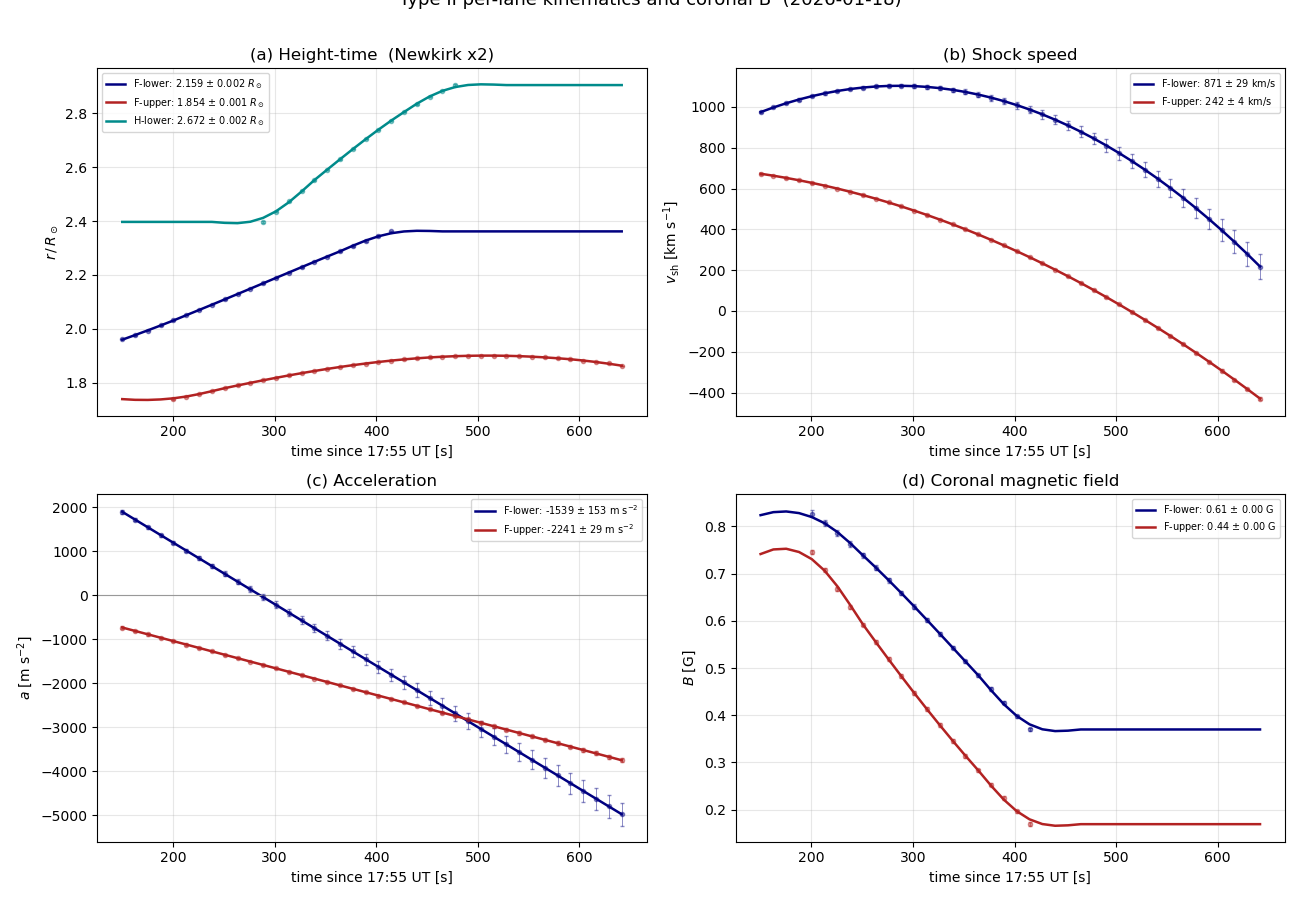

In [30]:
LANES4     = [('F', 'lower'), ('F', 'upper'), ('H', 'lower'), ('H', 'upper')]
LANE_COL   = {('F', 'lower'): 'navy', ('F', 'upper'): 'firebrick',
              ('H', 'lower'): 'darkcyan', ('H', 'upper'): 'magenta'}
AL = ALref

def _traced(lane, key):
    return np.isfinite(AL[lane][key + '_mean']).sum() > 2

fig, axs = plt.subplots(2, 2, figsize=[13, 9])
(axr, axv), (axa, axb) = axs

def lane_panel(ax, key, ylabel, unit, fmt='{:.3g}'):
    for ln in LANES4:
        if not _traced(ln, key):
            continue
        c = LANE_COL[ln]
        m, err = AL[ln][key + '_mean'], AL[ln][key + '_se']
        mbar = np.nanmean(m)
        sebar = np.sqrt(np.nanmean(err ** 2))
        ax.errorbar(tg, m, yerr=err, fmt='o', ms=3, color=c, ecolor=c,
                    elinewidth=0.7, capsize=1.5, alpha=0.45)
        ax.plot(tg, sg_smooth(m), '-', color=c, lw=1.8,
                label=f'{ln[0]}-{ln[1]}: {fmt.format(mbar)} $\\pm$ {fmt.format(sebar)} {unit}')
    ax.set_ylabel(ylabel); ax.set_xlabel(f'time since {t0.strftime("%H:%M")} UT [s]')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

lane_panel(axr, 'r', r'$r\,/\,R_\odot$', r'$R_\odot$', '{:.3f}')
axr.set_title(f'(a) Height-time  ({REF_MODEL_NAME})')
lane_panel(axv, 'v', r'$v_{\rm sh}$ [km s$^{-1}$]', 'km/s', '{:.0f}')
axv.set_title('(b) Shock speed')
lane_panel(axa, 'a', r'$a$ [m s$^{-2}$]', r'm s$^{-2}$', '{:.0f}')
axa.axhline(0, color='0.6', lw=0.8); axa.set_title('(c) Acceleration')
lane_panel(axb, 'B', r'$B$ [G]', 'G', '{:.2f}')
axb.set_title('(d) Coronal magnetic field')

fig.suptitle(f'Type II per-lane kinematics and coronal B  ({EVENT_DATE})', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'typeii_lane_kinematics_Bfield')
plt.show()


## 6&#160;&#183;&#160;Sensitivity to density model &#215; fold

The band-split **density jump $X$ and $M_A$ are model-independent** (they come only from the
frequency ratio), so they are quoted once. The **height, shock speed, Alfv&#233;n speed and $B$**
depend on the density model &#8212; below, each is grid-averaged over the burst for all
$5\times4$ model&#215;fold combinations, with Monte-Carlo error bars. The spread across the grid is
the density-model systematic, which dominates the statistical bars.

In [31]:
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k):
        return x

def pick_ref_lane(agg):
    for ln in [('F', 'lower'), ('H', 'lower'), ('F', 'upper'), ('H', 'upper')]:
        if np.isfinite(agg[ln]['r_mean']).sum() > 3:
            return ln
    return ('F', 'lower')

def grid_scalar(d, key):
    m, se = d[key + '_mean'], d[key + '_se']
    good = np.isfinite(m)
    if good.sum() == 0:
        return np.nan, np.nan
    return np.nanmean(m[good]), np.sqrt(np.nanmean(se[good] ** 2))

ref_lane = pick_ref_lane(ALref)
sweep_rows = []
for name, model in tqdm(MODEL_GRID.items(), desc='model x fold'):
    agg = aggregate_lanes(passes, tg, model)
    d = agg[ref_lane]
    row = {'model': name}
    for key, lab in [('r', 'r_Rsun'), ('v', 'v_kms'), ('vA', 'vA_kms'), ('B', 'B_G'), ('ne', 'ne_cm3')]:
        row[lab], row[lab + '_se'] = grid_scalar(d, key)
    sweep_rows.append(row)
sweep = pd.DataFrame(sweep_rows)
sweep['base'] = [m.rsplit(' x', 1)[0] for m in sweep['model']]
sweep['fold'] = [int(m.rsplit(' x', 1)[1]) for m in sweep['model']]
sweep.to_csv(os.path.join(OUTDIR, 'model_grid_sweep.csv'), index=False)
print(f'reference lane for the sweep: {ref_lane[0]}-{ref_lane[1]}')
sweep[['model', 'r_Rsun', 'v_kms', 'vA_kms', 'B_G']].round(3)

model x fold:   0%|          | 0/20 [00:00<?, ?it/s]

reference lane for the sweep: F-lower


,model,r_Rsun,v_kms,vA_kms,B_G
0,Newkirk x1,1.876,641.858,311.615,0.460
1,Newkirk x2,2.159,870.502,413.726,0.610
2,Newkirk x3,2.369,1066.647,498.650,0.734
3,Newkirk x4,2.544,1249.563,575.879,0.847
4,Saito x1,1.643,471.809,242.952,0.360
5,Saito x2,1.850,546.381,279.559,0.414
6,Saito x3,1.985,600.341,305.528,0.452
7,Saito x4,2.089,645.051,326.720,0.484
8,Leblanc x1,1.484,438.686,226.284,0.335
9,Leblanc x2,1.677,504.923,259.616,0.385


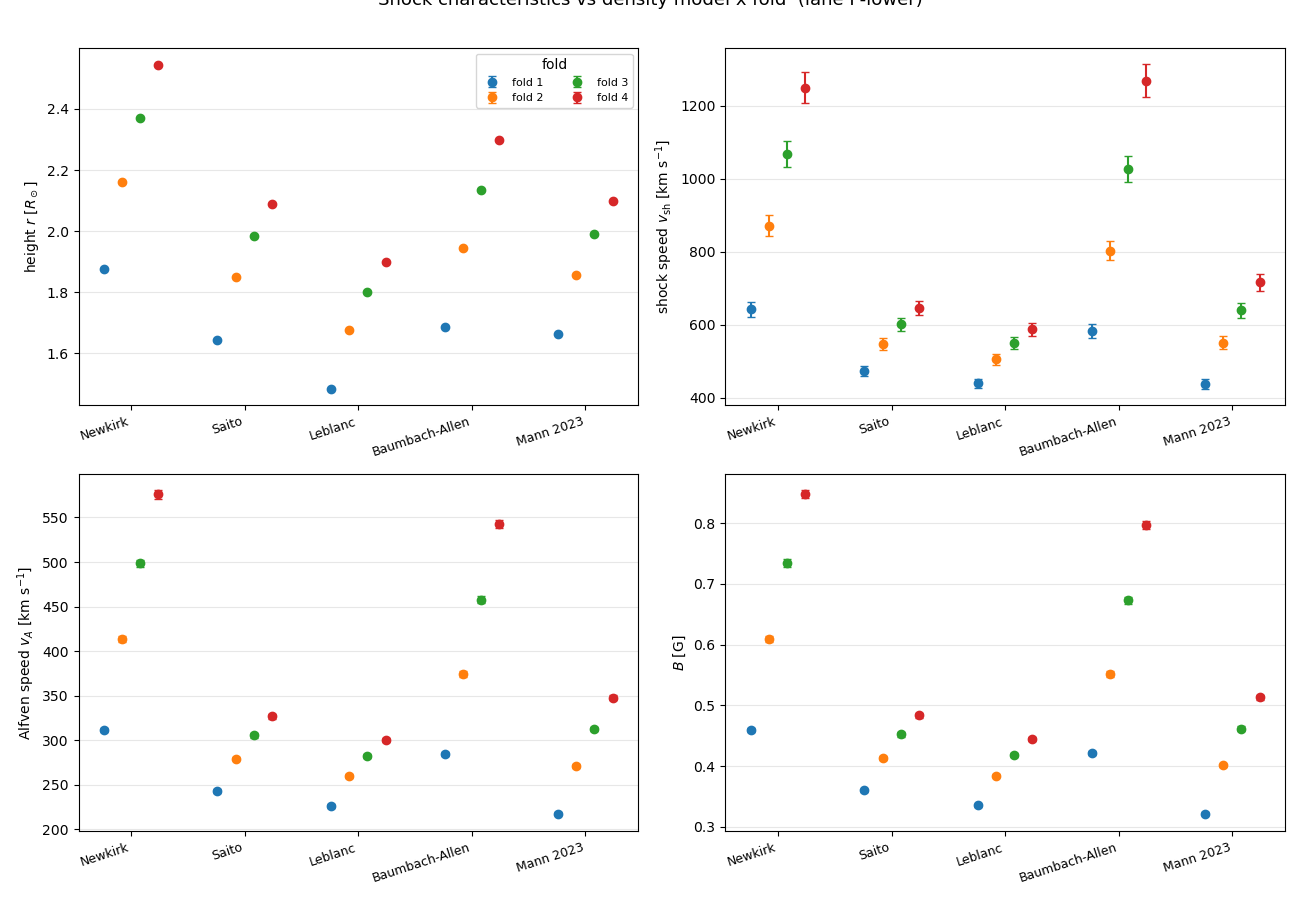

In [32]:
# each model-dependent characteristic across the model x fold grid, with error bars
bases = list(BASE_MODELS.keys())
xpos = np.arange(len(bases))
fold_off = {f: (f - 2.5) * 0.16 for f in FOLDS}
fold_col = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:green', 4: 'tab:red'}

panels = [('r_Rsun', r'height $r$ [$R_\odot$]'), ('v_kms', r'shock speed $v_{\rm sh}$ [km s$^{-1}$]'),
          ('vA_kms', r'Alfven speed $v_A$ [km s$^{-1}$]'), ('B_G', r'$B$ [G]')]

fig, axs = plt.subplots(2, 2, figsize=[13, 9])
for ax, (col, ylab) in zip(axs.ravel(), panels):
    for f in FOLDS:
        sub = sweep[sweep['fold'] == f].set_index('base').reindex(bases)
        ax.errorbar(xpos + fold_off[f], sub[col], yerr=sub[col + '_se'], fmt='o',
                    color=fold_col[f], ms=6, capsize=3, label=f'fold {f}')
    ax.set_xticks(xpos); ax.set_xticklabels(bases, rotation=18, ha='right', fontsize=9)
    ax.set_ylabel(ylab); ax.grid(alpha=0.3, axis='y')
axs[0, 0].legend(title='fold', fontsize=8, ncol=2)
fig.suptitle(f'Shock characteristics vs density model x fold  (lane {ref_lane[0]}-{ref_lane[1]})',
             y=1.01, fontsize=13)
fig.tight_layout()
# save_fig(fig, 'characteristics_vs_model_fold')
plt.show()


## 7&#160;&#183;&#160;Coronal magnetic field vs empirical $B(r)$ laws

The band-split estimate $B=v_A\sqrt{\mu_0\rho}$ (one point per model&#215;fold at the height that
model assigns, with error bars) is compared with three published radial-field laws: Dulk & McLean
(1978), Gopalswamy & Yashiro (2011, calibrated 6&#8211;23 $R_\odot$ so extrapolated here), and Mann
et al. (2023, Eq. 8).

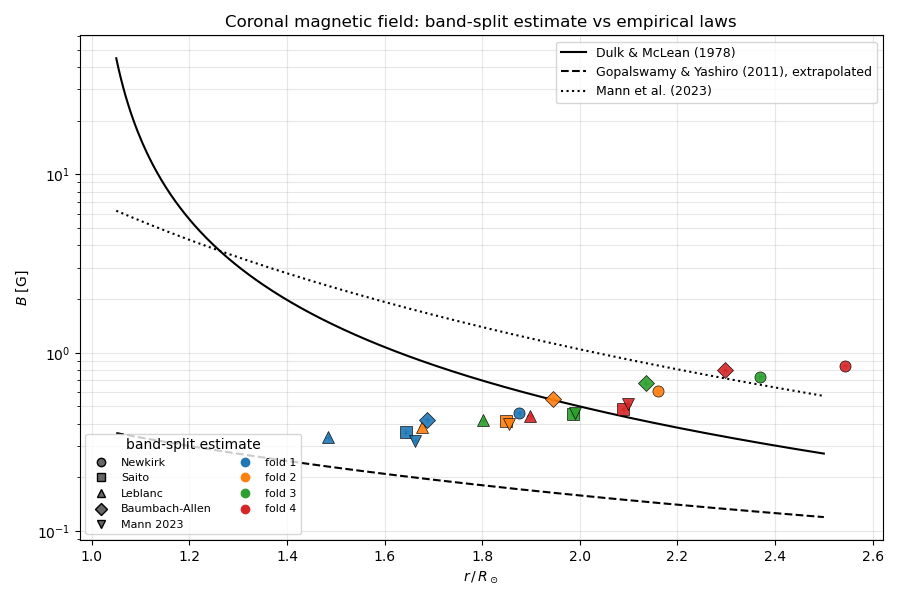

In [33]:
def B_dulk_mclean(r):
    """Dulk & McLean (1978); valid 1.02 <= r <= 10 Rsun."""
    r = np.asarray(r, float)
    return 0.5 * (r - 1.0) ** -1.5

def B_gopalswamy_yashiro(r):
    """Gopalswamy & Yashiro (2011) headline fit (calibrated 6-23 Rsun; extrapolated below)."""
    r = np.asarray(r, float)
    return 0.377 * r ** -1.25

def B_mann2023(r):
    """Mann et al. (2023), A&A 679, A64, Eq. 8 radial field [G]."""
    r = np.asarray(r, float)
    return 6.0 * r ** -3 + 1.18 * r ** -2

rr = np.linspace(1.05, 2.5, 300)
fig, ax = plt.subplots(figsize=[9, 6])
ax.plot(rr, B_dulk_mclean(rr), 'k-', label='Dulk & McLean (1978)')
ax.plot(rr, B_gopalswamy_yashiro(rr), 'k--', label='Gopalswamy & Yashiro (2011), extrapolated')
ax.plot(rr, B_mann2023(rr), 'k:', label='Mann et al. (2023)')

# band-split estimate: one marker per model x fold at (grid-mean height, grid-mean B)
mk = {'Newkirk': 'o', 'Saito': 's', 'Leblanc': '^', 'Baumbach-Allen': 'D', 'Mann 2023': 'v'}
for _, row in sweep.iterrows():
    if np.isfinite(row['r_Rsun']) and np.isfinite(row['B_G']):
        ax.errorbar(row['r_Rsun'], row['B_G'], yerr=row['B_G_se'], xerr=row['r_Rsun_se'],
                    fmt=mk[row['base']], color=fold_col[row['fold']], ms=8, capsize=2,
                    mec='k', mew=0.5, alpha=0.9)
handles = [plt.Line2D([], [], marker=mk[b], color='0.4', ls='', mec='k', label=b) for b in bases]
handles += [plt.Line2D([], [], marker='o', color=fold_col[f], ls='', label=f'fold {f}') for f in FOLDS]
leg1 = ax.legend(loc='upper right', fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=handles, loc='lower left', fontsize=8, ncol=2, title='band-split estimate')
ax.set_yscale('log'); ax.set_xlabel(r'$r\,/\,R_\odot$'); ax.set_ylabel(r'$B$ [G]')
ax.set_title('Coronal magnetic field: band-split estimate vs empirical laws'); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
# save_fig(fig, 'Bfield_comparison')
plt.show()

## 8&#160;&#183;&#160;Characteristics table and saved picks

In [34]:
# assemble the headline characteristics table (reference model + model-independent scalars)
rows = []
for b in ('F', 'H'):
    s = scalars[b]
    rows.append({'quantity': f'drift rate ({b})', 'value': s['drift_MHz_s'][0],
                 'error': s['drift_MHz_s'][1], 'unit': 'MHz/s', 'note': 'model-independent'})
    rows.append({'quantity': f'density jump X ({b})', 'value': s['X'][0], 'error': s['X'][1],
                 'unit': '-', 'note': 'model-independent'})
    rows.append({'quantity': f'Alfven Mach number M_A ({b})', 'value': s['M_A'][0], 'error': s['M_A'][1],
                 'unit': '-', 'note': 'model-independent'})
    rows.append({'quantity': f'relative bandwidth ({b})', 'value': s['rel_bandwidth'][0],
                 'error': s['rel_bandwidth'][1], 'unit': '-', 'note': 'model-independent'})
for lane in LANES4:
    d = ALref[lane]
    if np.isfinite(d['r_mean']).sum() <= 2:
        continue
    tag = f'{lane[0]}-{lane[1]}'
    for key, lab, unit in [('r', 'height r', 'Rsun'), ('v', 'shock speed', 'km/s'),
                           ('a', 'acceleration', 'm/s^2'), ('vA', 'Alfven speed', 'km/s'),
                           ('B', 'magnetic field B', 'G')]:
        m, se = grid_scalar(d, key)
        rows.append({'quantity': f'{lab} ({tag})', 'value': m, 'error': se, 'unit': unit,
                     'note': REF_MODEL_NAME})
    v_mean, _ = grid_scalar(d, 'v')
    rows.append({'quantity': f'exciter e- energy ({tag})',
                 'value': electron_energy_from_speed(v_mean) * 1e3, 'error': np.nan,
                 'unit': 'eV', 'note': f'{REF_MODEL_NAME}, E=(gamma-1)m_e c^2 at v_sh'})

char_table = pd.DataFrame(rows)
char_table.to_csv(os.path.join(OUTDIR, 'typeii_characteristics.csv'), index=False)

with open(os.path.join(OUTDIR, 'typeii_bezier_picks.pkl'), 'wb') as fh:
    pickle.dump({'bezier_specs': bezier_specs, 'passes': passes,
                 'config': {'TYPEII_WINDOW': TYPEII_WINDOW, 'TYPEII_FLIM': TYPEII_FLIM,
                            'HARM': HARM, 'REF_MODEL_NAME': REF_MODEL_NAME,
                            'BEZIER_ANCHORS': BEZIER_ANCHORS}}, fh)
print('saved typeii_characteristics.csv, model_grid_sweep.csv, typeii_bezier_picks.pkl to', OUTDIR)
char_table.round(3)

saved typeii_characteristics.csv, model_grid_sweep.csv, typeii_bezier_picks.pkl to ./type2_lwa_bezier_outputs


,quantity,value,error,unit,note
0,drift rate (F),-0.043,0.000,MHz/s,model-independent
1,density jump X (F),2.574,0.007,-,model-independent
2,Alfven Mach number M_A (F),2.647,0.013,-,model-independent
3,relative bandwidth (F),0.603,0.002,-,model-independent
4,drift rate (H),-0.066,0.001,MHz/s,model-independent
5,density jump X (H),NaN,NaN,-,model-independent
6,Alfven Mach number M_A (H),NaN,NaN,-,model-independent
7,relative bandwidth (H),NaN,NaN,-,model-independent
8,height r (F-lower),2.159,0.002,Rsun,Newkirk x2
9,shock speed (F-lower),870.502,28.817,km/s,Newkirk x2



### Conventions and caveats

- **Emission harmonic.** Set `HARM` per band; the F/H assignment controls the frequency&#8594;density
  factor ($s=1$ or $2$) and therefore the height, speed and $B$. Re-run after changing it.
- **Model-independent vs model-dependent.** $X$, $M_A$, drift rate and bandwidth depend only on the
  traced frequencies; height, speed, $v_A$ and $B$ depend on the density model &#8212; that spread
  (&#167;6) is the real uncertainty budget, larger than the statistical bars.
- **Exciter electron energy** is $(\gamma-1)m_ec^2$ at the shock speed &#8212; the bulk exciter
  energy, not a relativistic beam; the same estimator gives fast type III beam energies if a lane is
  a beam rather than a shock.
- **$M_A$ validity.** Rankine&#8211;Hugoniot inversion needs $1\le X<4$; band splits with $X\ge4$
  return NaN.
- **Mann (2023)** density is valid to $\sim3\,R_\odot$; Gopalswamy & Yashiro (2011) $B(r)$ is
  extrapolated below its 6&#8211;23 $R_\odot$ calibration range.